In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,f1_score,confusion_matrix,ConfusionMatrixDisplay,accuracy_score
from xgboost import XGBClassifier

In [8]:

np.random.seed(42)

n_students = 500

data = pd.DataFrame({
    "study_hours": np.random.randint(1, 11, n_students),
    "attendance_rate": np.random.randint(40, 101, n_students),
    "previous_score": np.random.randint(30, 101, n_students),
    "sleep_hours": np.random.randint(4, 10, n_students),
    "assignments_done": np.random.randint(0, 11, n_students)
})

score = (
    data["study_hours"] * 4
    + data["attendance_rate"] * 0.25
    + data["previous_score"] * 0.45
    + data["sleep_hours"] * 2
    + data["assignments_done"] * 3
    + np.random.normal(0, 7, n_students)
)

data["passed_exam"] = np.where(score >= 95, 1, 0)

data.head()

,study_hours,attendance_rate,previous_score,sleep_hours,assignments_done,passed_exam
0,7,80,99,4,9,1
1,4,69,62,5,3,0
2,8,56,82,6,4,1
3,5,88,51,9,1,0
4,7,59,50,8,7,0


In [9]:
X = data.drop("passed_exam", axis=1)

y = data["passed_exam"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,study_hours,attendance_rate,previous_score,sleep_hours,assignments_done
0,7,80,99,4,9
1,4,69,62,5,3
2,8,56,82,6,4
3,5,88,51,9,1
4,7,59,50,8,7



Target:


0    1
1    0
2    1
3    0
4    0
Name: passed_exam, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,

)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (400, 5)
Test size: (100, 5)


In [11]:
model = XGBClassifier(
    n_estimators=100,        
    learning_rate=0.1,       
    max_depth=3,             

    subsample=0.8,           
    colsample_bytree=0.8,   )

In [12]:
model.fit(X_train, y_train)   


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [13]:
y_pred = model.predict(X_test)

y_pred_proba = model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Probability_Pass": np.round(y_pred_proba, 3)
})

results.head(10)

,Actual,Predicted,Probability_Pass
0,0,0,0.432
1,0,0,0.322
2,1,1,0.993
3,0,0,0.123
4,1,1,0.986
5,1,1,0.992
6,0,0,0.071
7,0,1,0.884
8,1,1,0.678
9,1,1,0.991


In [14]:
print(accuracy_score(y_pred,y_test))

0.9


In [15]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.80      0.97      0.88        36
           1       0.98      0.86      0.92        64

    accuracy                           0.90       100
   macro avg       0.89      0.92      0.90       100
weighted avg       0.91      0.90      0.90       100



In [17]:
feature_importance = pd.DataFrame({
    "feature":X.columns,
    "importance":model.feature_importances_
})
feature_importance  = feature_importance.sort_values(
    by = "importance",
    ascending= False
)
feature_importance

,feature,importance
0,study_hours,0.329958
2,previous_score,0.221819
4,assignments_done,0.197921
1,attendance_rate,0.130572
3,sleep_hours,0.119729


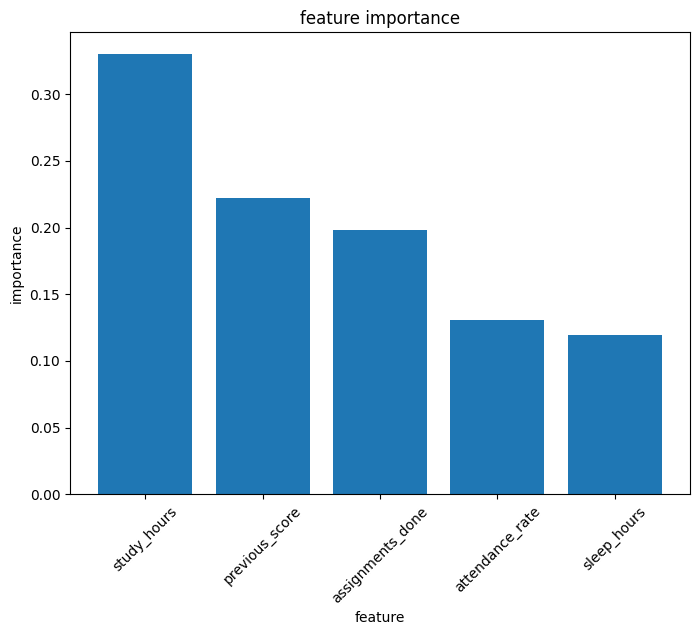

In [18]:
plt.figure(figsize=(8,6))

plt.bar(
    feature_importance['feature'],
    feature_importance['importance']
)
plt.title('feature importance')
plt.xlabel('feature')
plt.ylabel('importance')
plt.xticks(rotation=45)
plt.show()

In [21]:
new_student = pd.DataFrame({
    "study_hours":[2],
    "attendance_rate":[60],
    "previous_score":[70],
    "sleep_hours":[4],
    "assignments_done":[6]
})

new_prediction = model.predict(new_student)
new_probability = model.predict_proba(new_student)[:,1]

print("predicted class:",new_prediction[0])
print("probability of passing",round(new_probability[0],3))

if new_prediction[0] == 1:
    print('result: pass')
else:
    print('result:fail')

predicted class: 0
probability of passing 0.096
result:fail
